### Plotting the Normalised Frequency for ech length in query.bed

Calculating the fragment length and normalising them.

In [9]:
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import random

varFragCountMap = defaultdict(int)
varFragTotal = 0
with open("query.bed", "r") as varFile:
    for varLine in varFile:
        varCols = varLine.strip().split()
        varStart = int(varCols[1])
        varEnd = int(varCols[2])
        varFragLen = varEnd - varStart
        if varFragLen > 0:
            varFragCountMap[varFragLen] += 1
            varFragTotal += 1

varFragLenList = sorted(varFragCountMap)
varNormFreqList = [varFragCountMap[varL] / varFragTotal for varL in varFragLenList]

Plotting the Fragment Length vs. Normalised Frequency.

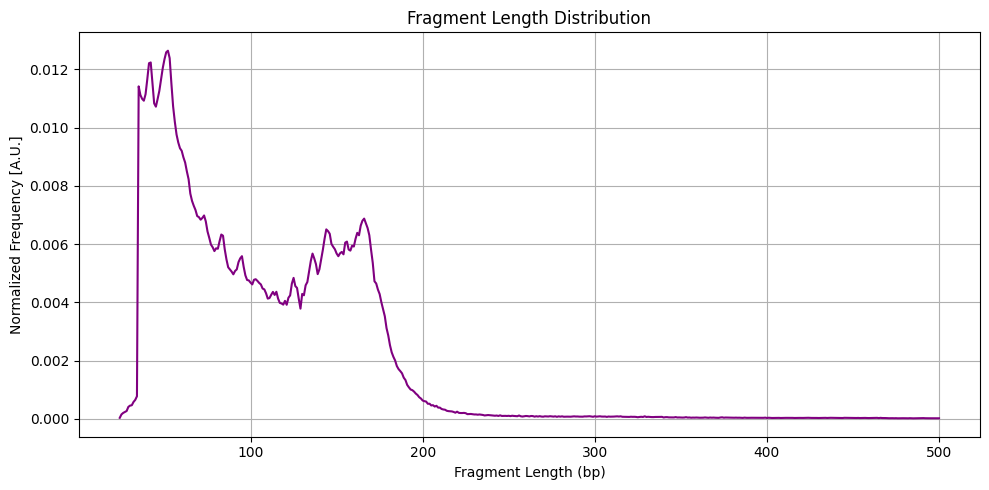

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(varFragLenList, varNormFreqList, color='purple')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Rescaling of query along the reference.

Loading query.bed and compute raw length distribution.

In [11]:
varQueryFragList = []
varQueryRecList = []

with open("query.bed", "r") as varFile:
    for varLine in varFile:
        varCols = varLine.strip().split()
        if len(varCols) < 3:
            continue
        try:
            varStart = int(varCols[1])
            varEnd = int(varCols[2])
            varFragLen = varEnd - varStart
            if varFragLen > 0:
                varQueryFragList.append(varFragLen)
                varQueryRecList.append(varLine)
        except ValueError:
            continue

Loading the reference data and normalising it.

In [12]:
varRefDist = {}
with open("reference.hist", "r") as varRefFile:
    for varRefLine in varRefFile:
        varParts = varRefLine.strip().split()
        if len(varParts) >= 2:
            varFragLen = int(varParts[0])
            varFreqVal = float(varParts[1])
            varRefDist[varFragLen] = varFreqVal

varRefTotal = sum(varRefDist.values())
varRefNormDict = {varL: varF / varRefTotal for varL, varF in varRefDist.items()}

Subsampling queries to match it with reference.

In [13]:
varQueryLenDict = defaultdict(list)
for varIdx, varFragLen in enumerate(varQueryFragList):
    varQueryLenDict[varFragLen].append(varIdx)

varTargetTotal = len(varQueryFragList)
varRescaledIndList = []

for varFragLen, varRefProbVal in varRefNormDict.items():
    varTargetCount = int(varRefProbVal * varTargetTotal)
    varAvailable = varQueryLenDict.get(varFragLen, [])
    varSampled = random.sample(varAvailable, min(varTargetCount, len(varAvailable)))
    varRescaledIndList.extend(varSampled)

varRescaledFragList = [varQueryFragList[varI] for varI in varRescaledIndList]

Computing the frequency distributions for query, reference and resampled query.

In [14]:
# Original query
varOrigCountMap = defaultdict(int)
for varL in varQueryFragList:
    varOrigCountMap[varL] += 1
varOrigTotal = len(varQueryFragList)
varOrigLenList = sorted(varOrigCountMap)
varOrigFreqList = [varOrigCountMap[varL] / varOrigTotal for varL in varOrigLenList]

# Reference
varRefLenList = sorted(varRefNormDict)
varRefFreqList = [varRefNormDict[varL] for varL in varRefLenList]

# Rescaled query
varResCountMap = defaultdict(int)
for varL in varRescaledFragList:
    varResCountMap[varL] += 1
varResTotal = len(varRescaledFragList)
varResLenList = sorted(varResCountMap)
varResFreqList = [varResCountMap[varL] / varResTotal for varL in varResLenList]

Plotting the original query vs. reference vs rescaled query.

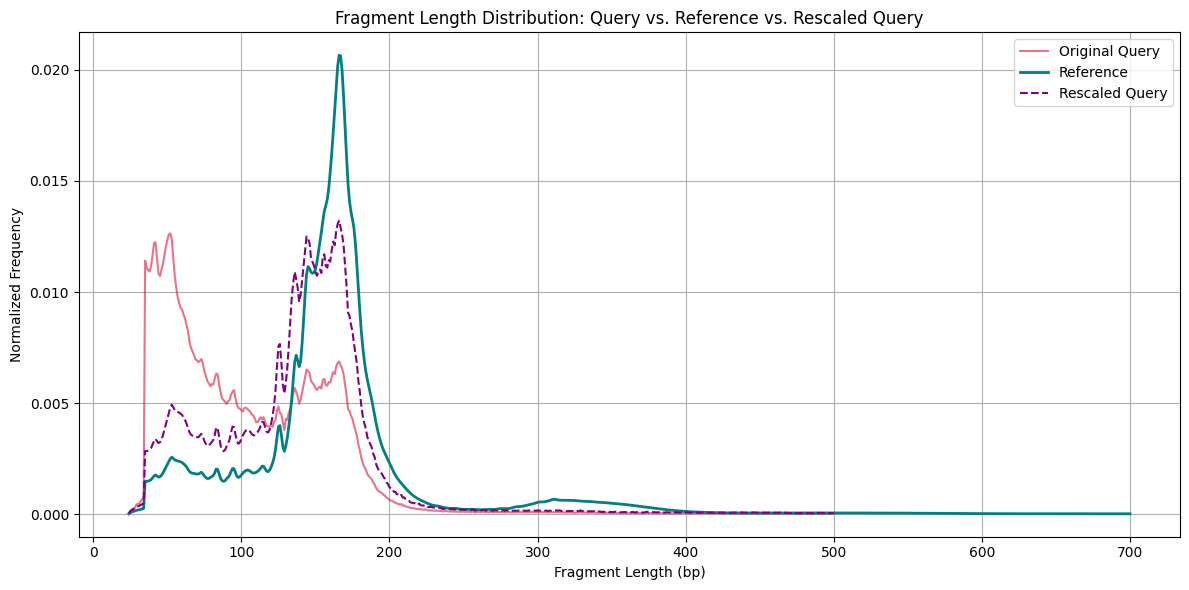

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(varOrigLenList, varOrigFreqList, label="Original Query", color='crimson', alpha=0.6)
plt.plot(varRefLenList, varRefFreqList, label="Reference", color='teal', linewidth=2)
plt.plot(varResLenList, varResFreqList, label="Rescaled Query", color='purple', linestyle='--')

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Fragment Length Distribution: Query vs. Reference vs. Rescaled Query")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Plotting with Binned Sampling.

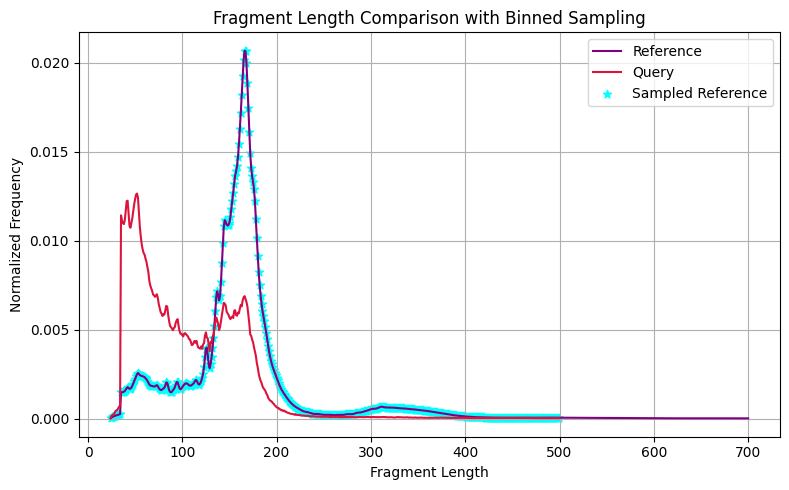

In [20]:
varQueryDF = pd.read_csv('query.bed', sep='\t', header=None)
varQueryDF.columns = ['Chrom', 'Start', 'End', 'Length', 'Dot', 'Strand']

varRefDF = pd.read_csv('reference.hist', header=None, sep='\t')

varRefDF[0] = pd.to_numeric(varRefDF[0], errors='coerce')

varBinEdges = list(range(0, 510, 10))
varBinLabels = [f"{varI}-{varI+10}" for varI in range(0, 500, 10)]

varQueryDF['Bin'] = pd.cut(varQueryDF['Length'], bins=varBinEdges, labels=varBinLabels, right=False)
varRefDF['Bin'] = pd.cut(varRefDF[0], bins=varBinEdges, labels=varBinLabels, right=False)

varQueryBinCounts = varQueryDF['Bin'].value_counts().sort_index()
varRefBinCounts = varRefDF['Bin'].value_counts().sort_index()

varMatchedSampleRows = []

for varBinLabel in varBinLabels:
    varCountQuery = varQueryBinCounts.get(varBinLabel, 0)
    varCountRef = varRefBinCounts.get(varBinLabel, 0)
    varSampleSize = min(varCountQuery, varCountRef)
    if varSampleSize > 0:
        varRefSubset = varRefDF[varRefDF['Bin'] == varBinLabel]
        varSampleSubset = varRefSubset.sample(n=varSampleSize, random_state=42)
        varMatchedSampleRows.append(varSampleSubset)

if varMatchedSampleRows:
    varRefSampledDF = pd.concat(varMatchedSampleRows, ignore_index=True)
else:
    varRefSampledDF = pd.DataFrame(columns=varRefDF.columns)

varLenCounts = varQueryDF['Length'].value_counts().sort_index()
varLenFreq = varLenCounts / varLenCounts.sum()
varQueryFreqDF = pd.DataFrame({'Length': varLenFreq.index, 'Frequency': varLenFreq.values})

plt.figure(figsize=(8, 5))
plt.plot(varRefDF[0], varRefDF[1], color='purple', label='Reference')
plt.plot(varQueryFreqDF['Length'], varQueryFreqDF['Frequency'], color='crimson', label='Query')
plt.scatter(varRefSampledDF[0], varRefSampledDF[1], color='cyan', marker='*', label='Sampled Reference')

plt.title('Fragment Length Comparison with Binned Sampling')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()